In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

<>:56: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:67: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:68: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:56: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:67: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:68: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_50292/1674421149.py:56: SyntaxWarning: "\l" is an invalid esc

✅ Exportado: ../results/charts/sparse/N_100/dashboard_analise.png


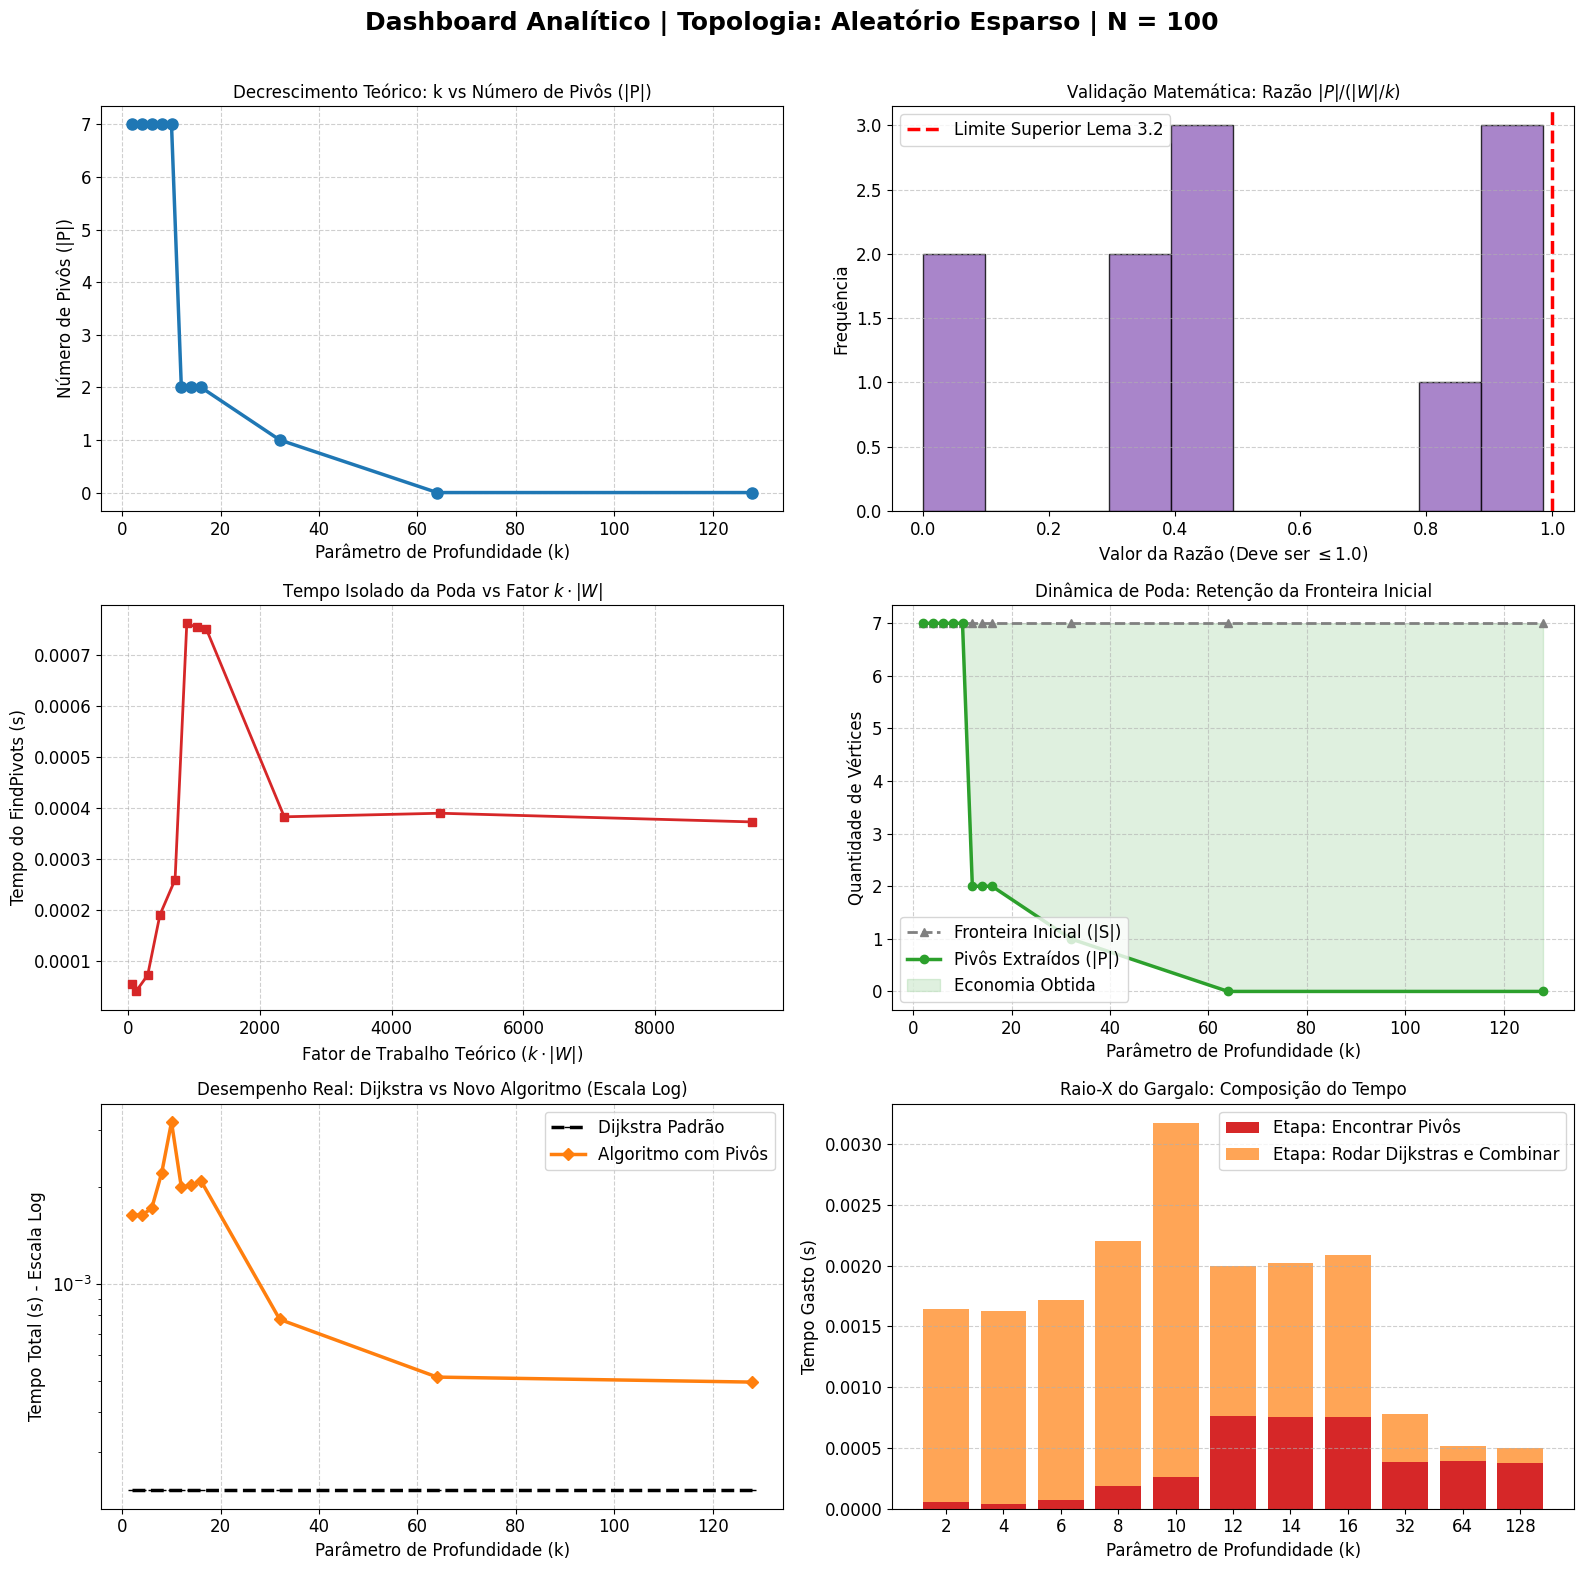

✅ Exportado: ../results/charts/sparse/N_500/dashboard_analise.png


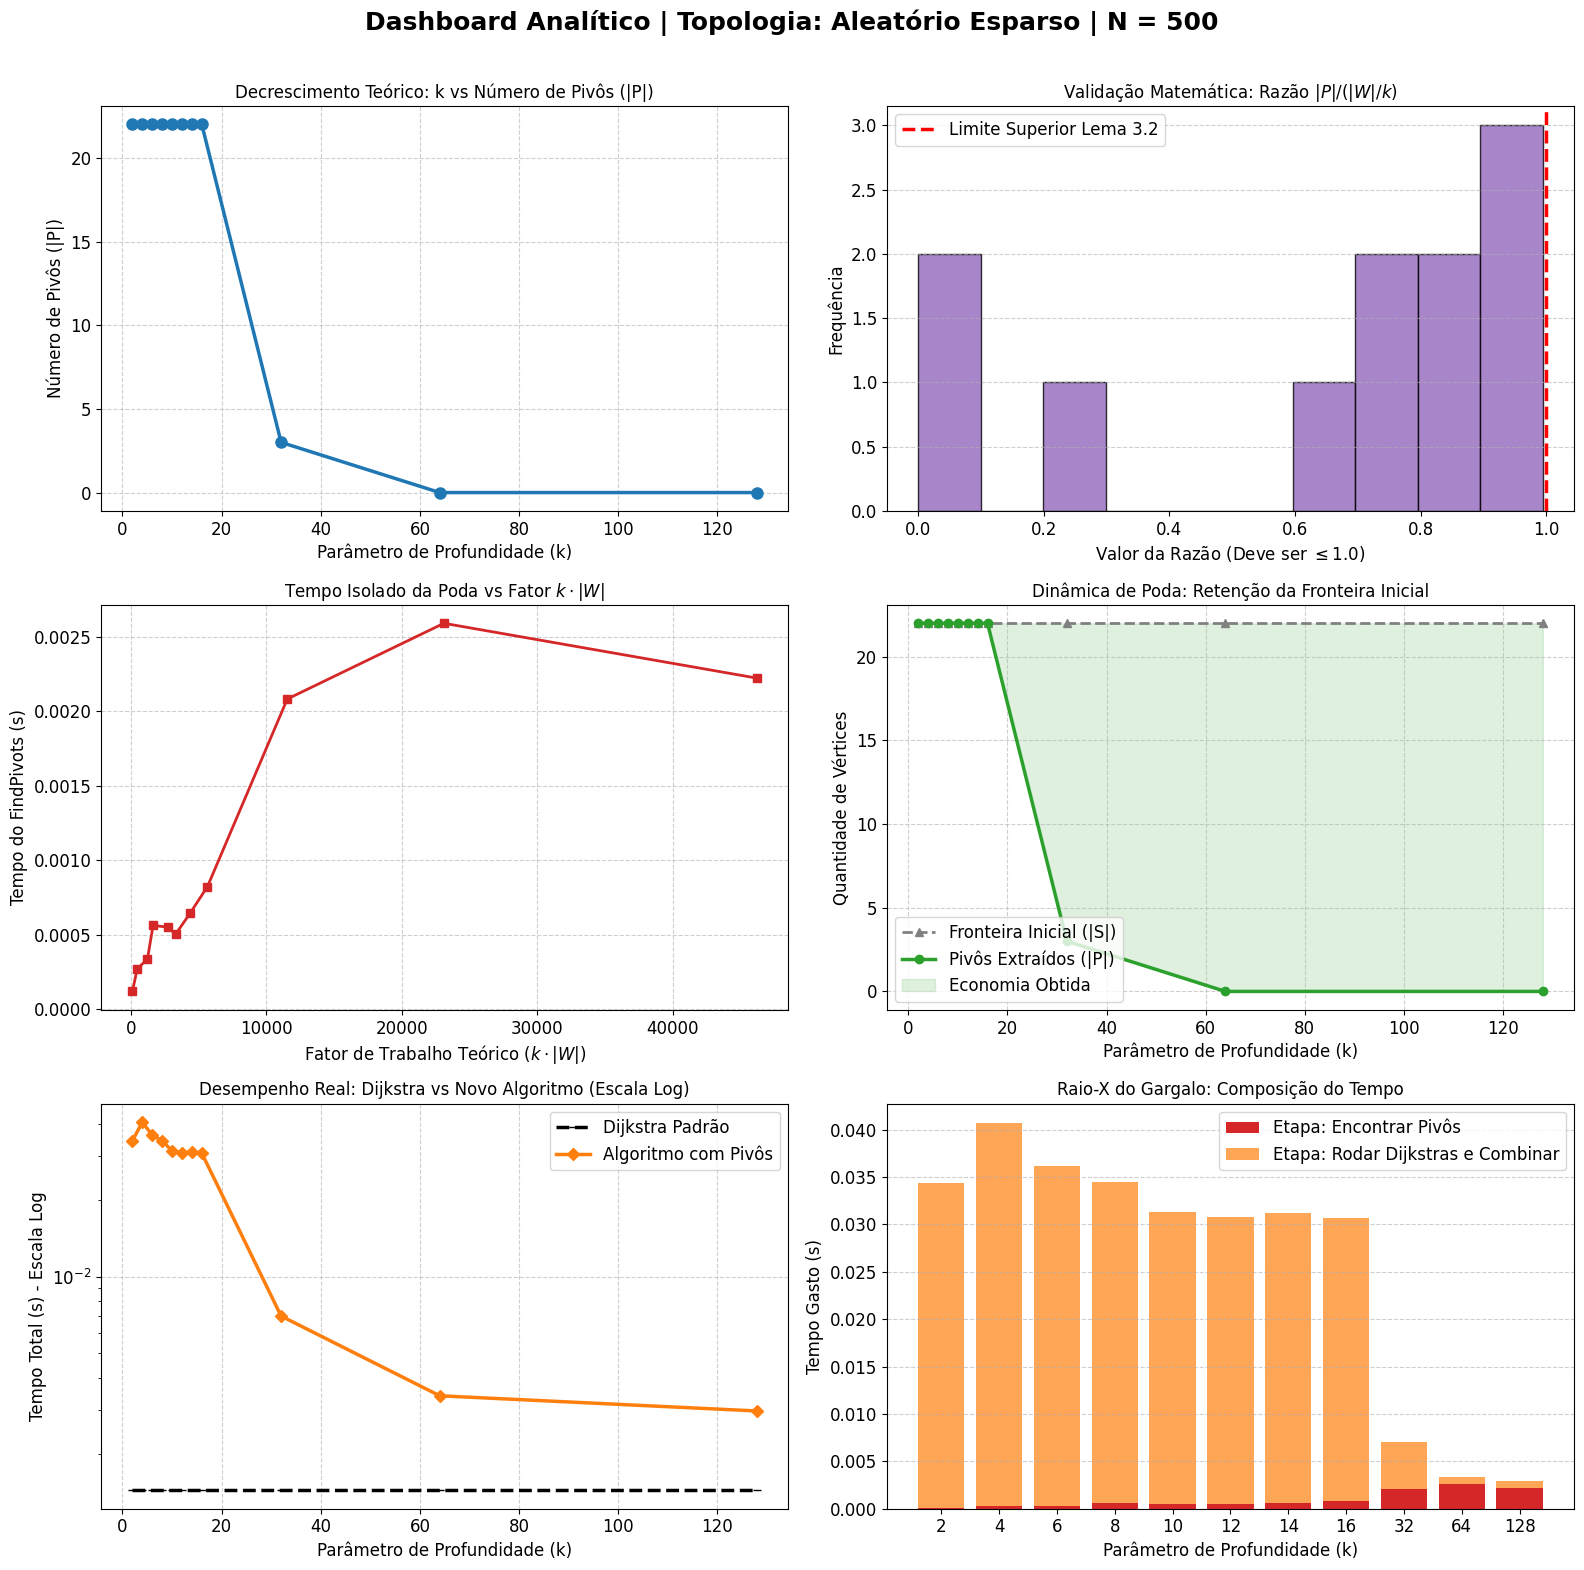

✅ Exportado: ../results/charts/sparse/N_1000/dashboard_analise.png


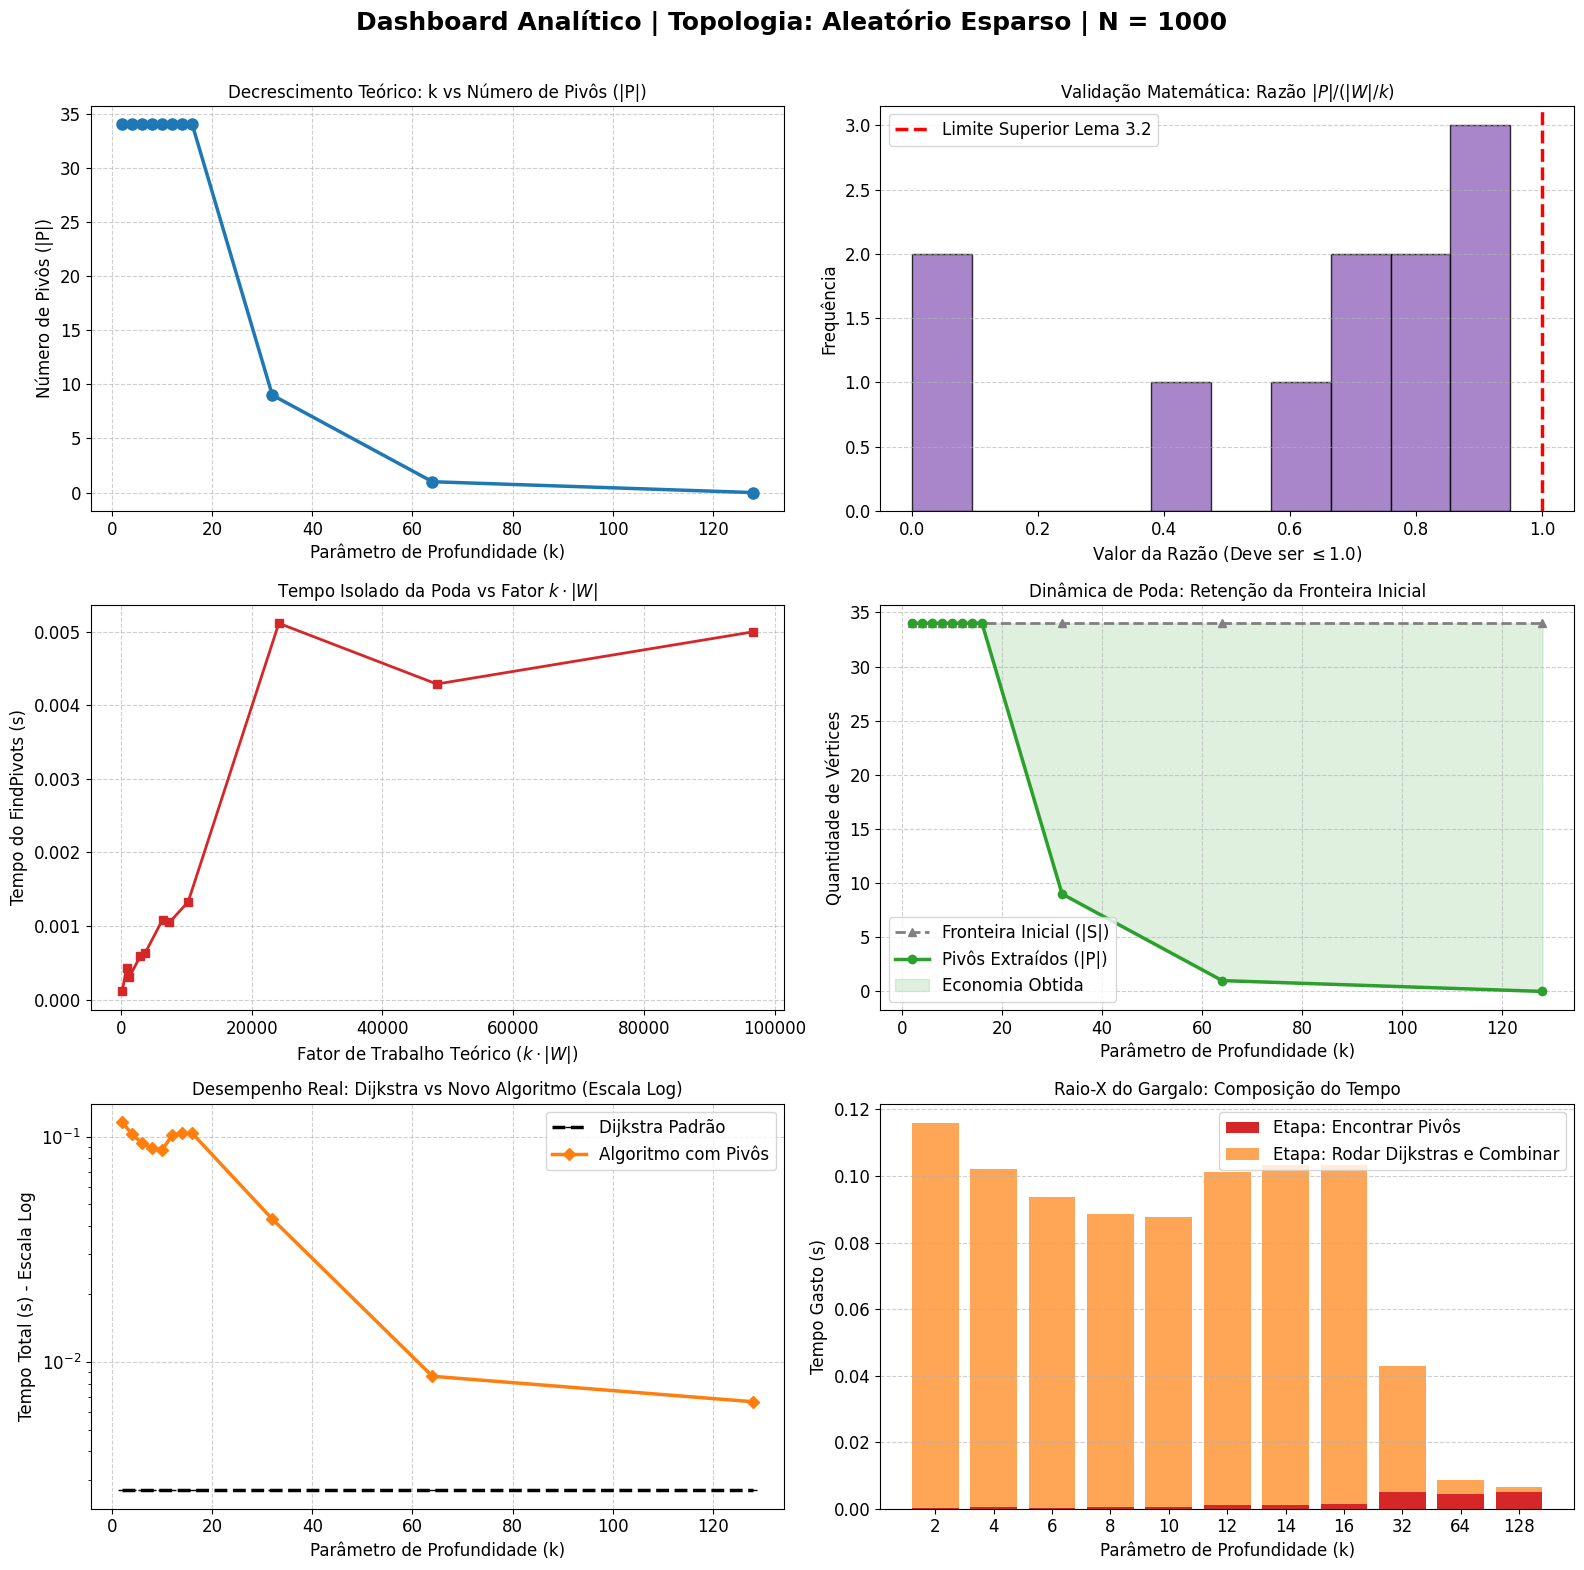

✅ Exportado: ../results/charts/sparse/N_5000/dashboard_analise.png


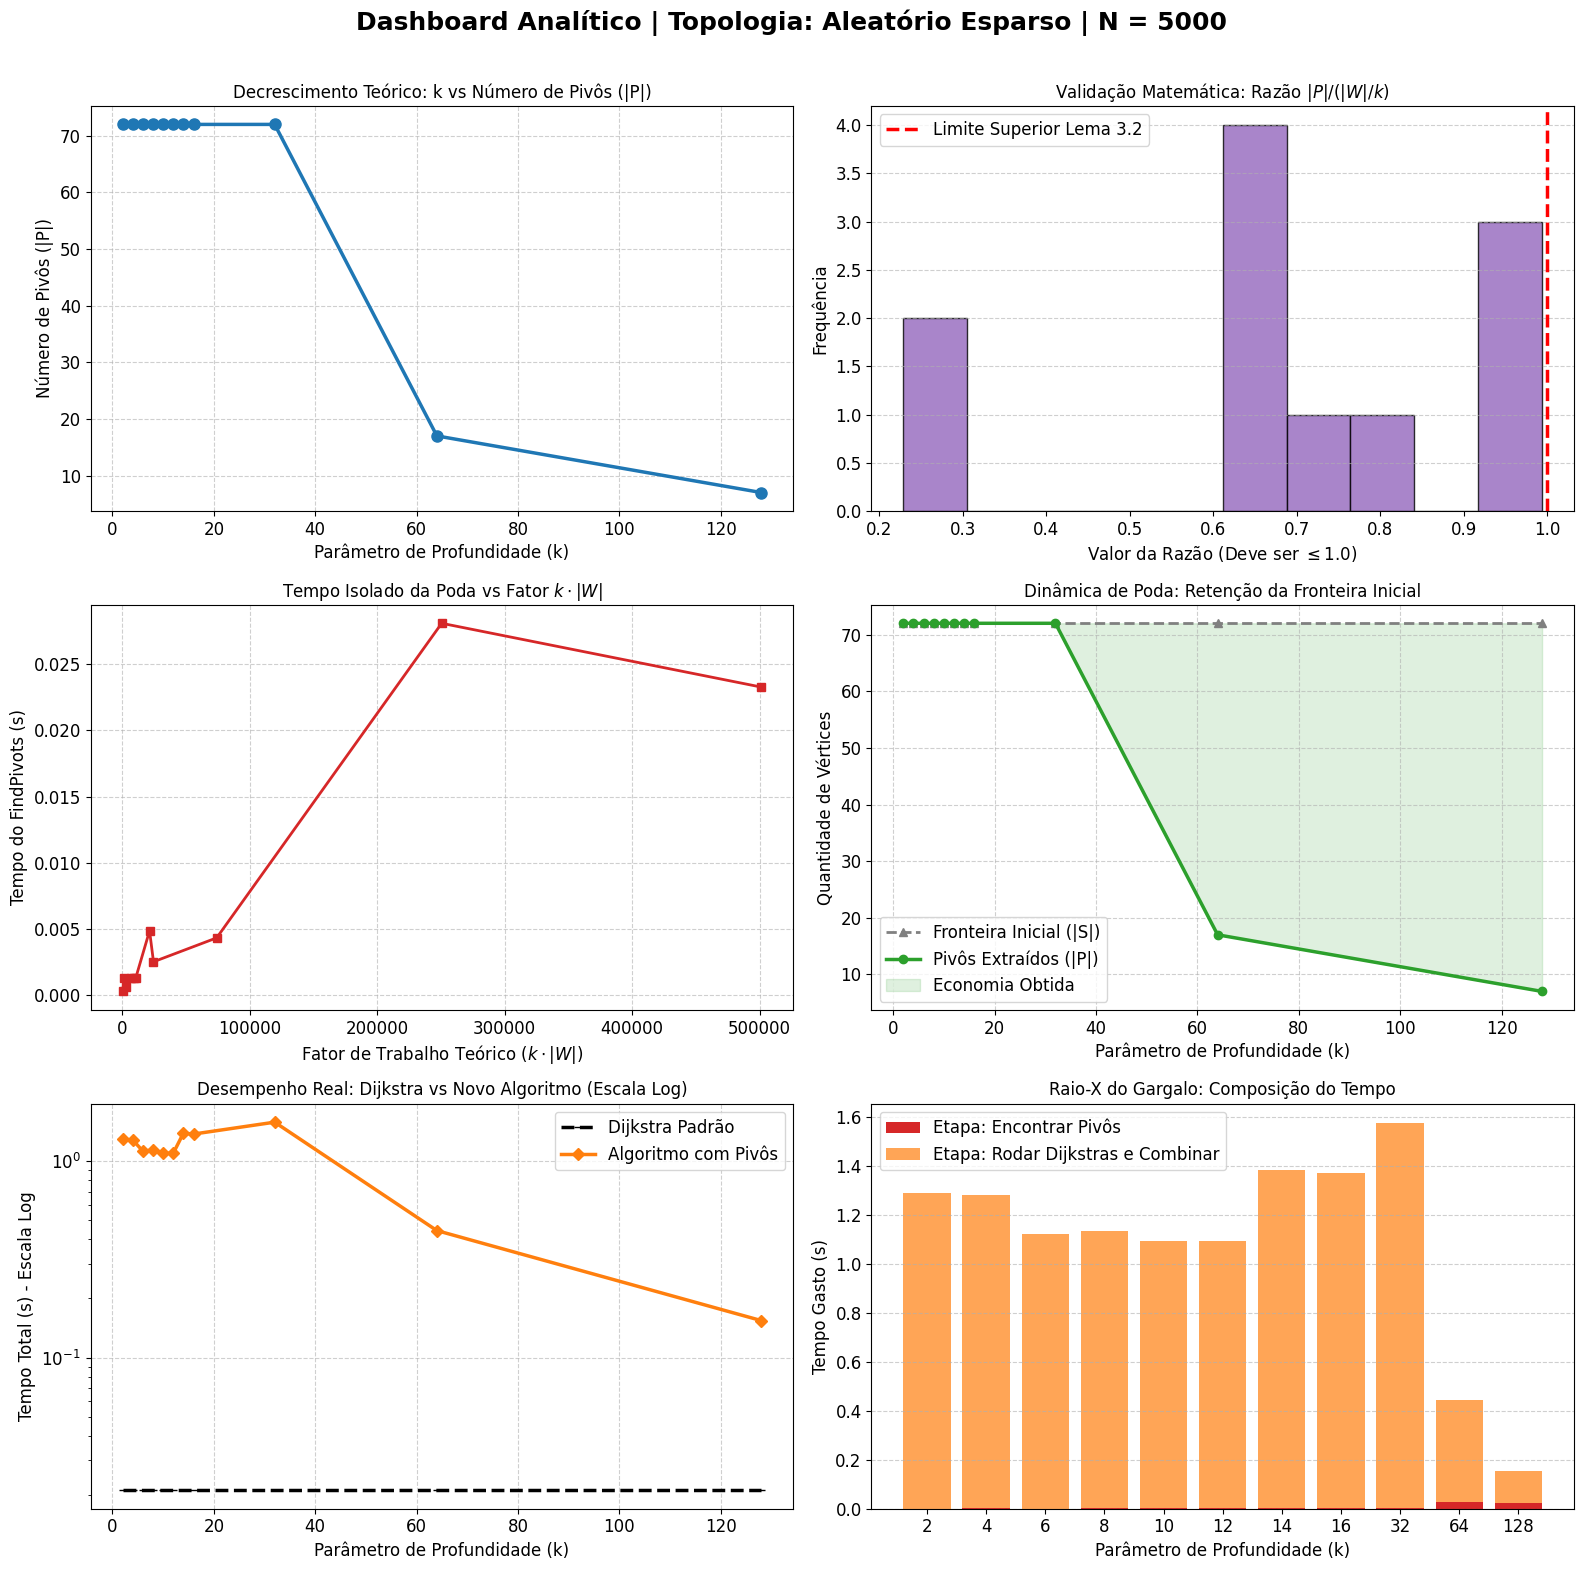

✅ Exportado: ../results/charts/sparse/N_10000/dashboard_analise.png


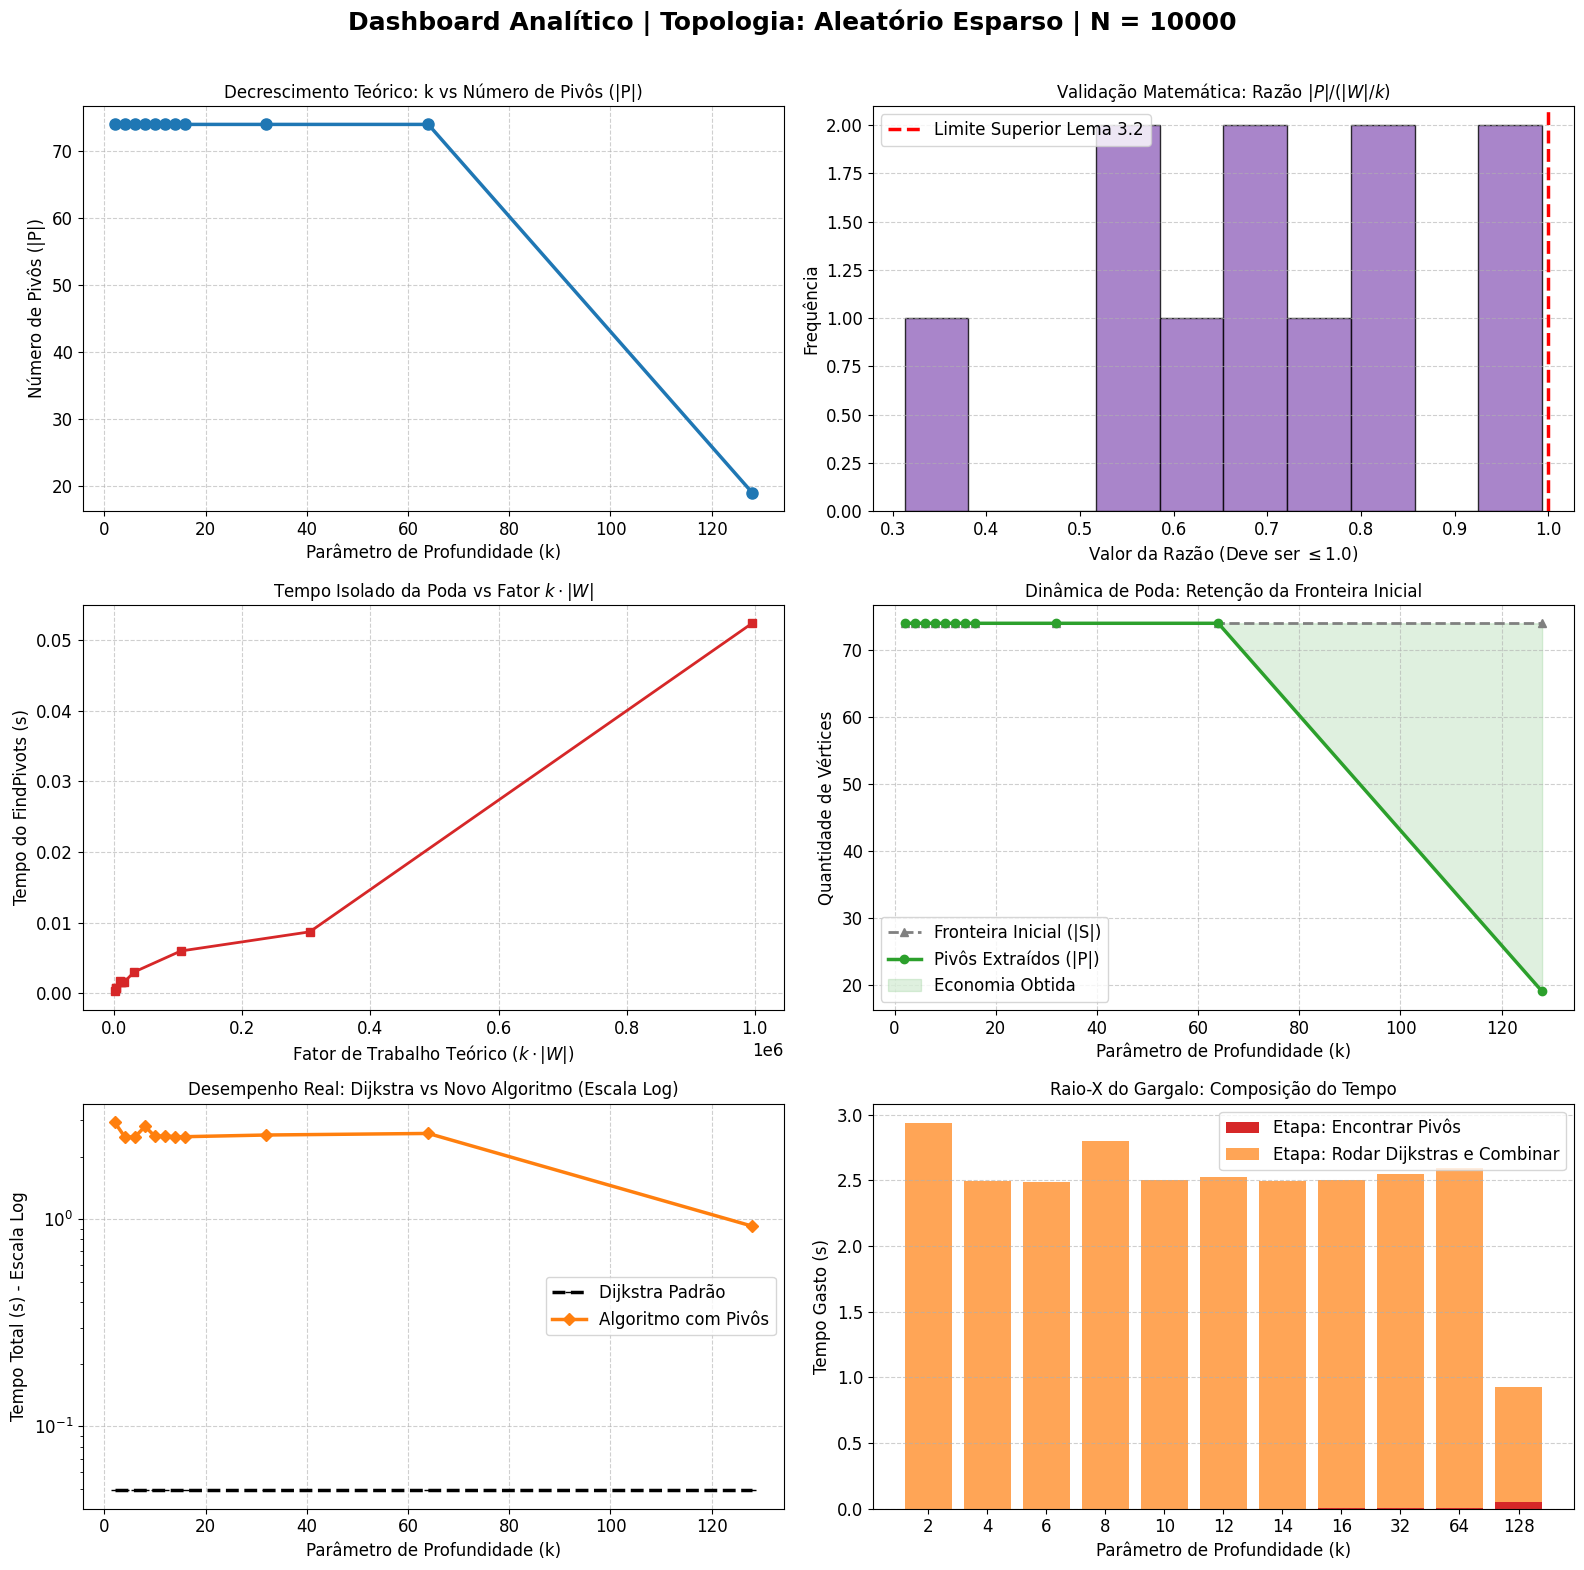

✅ Exportado: ../results/charts/grid/N_961/dashboard_analise.png


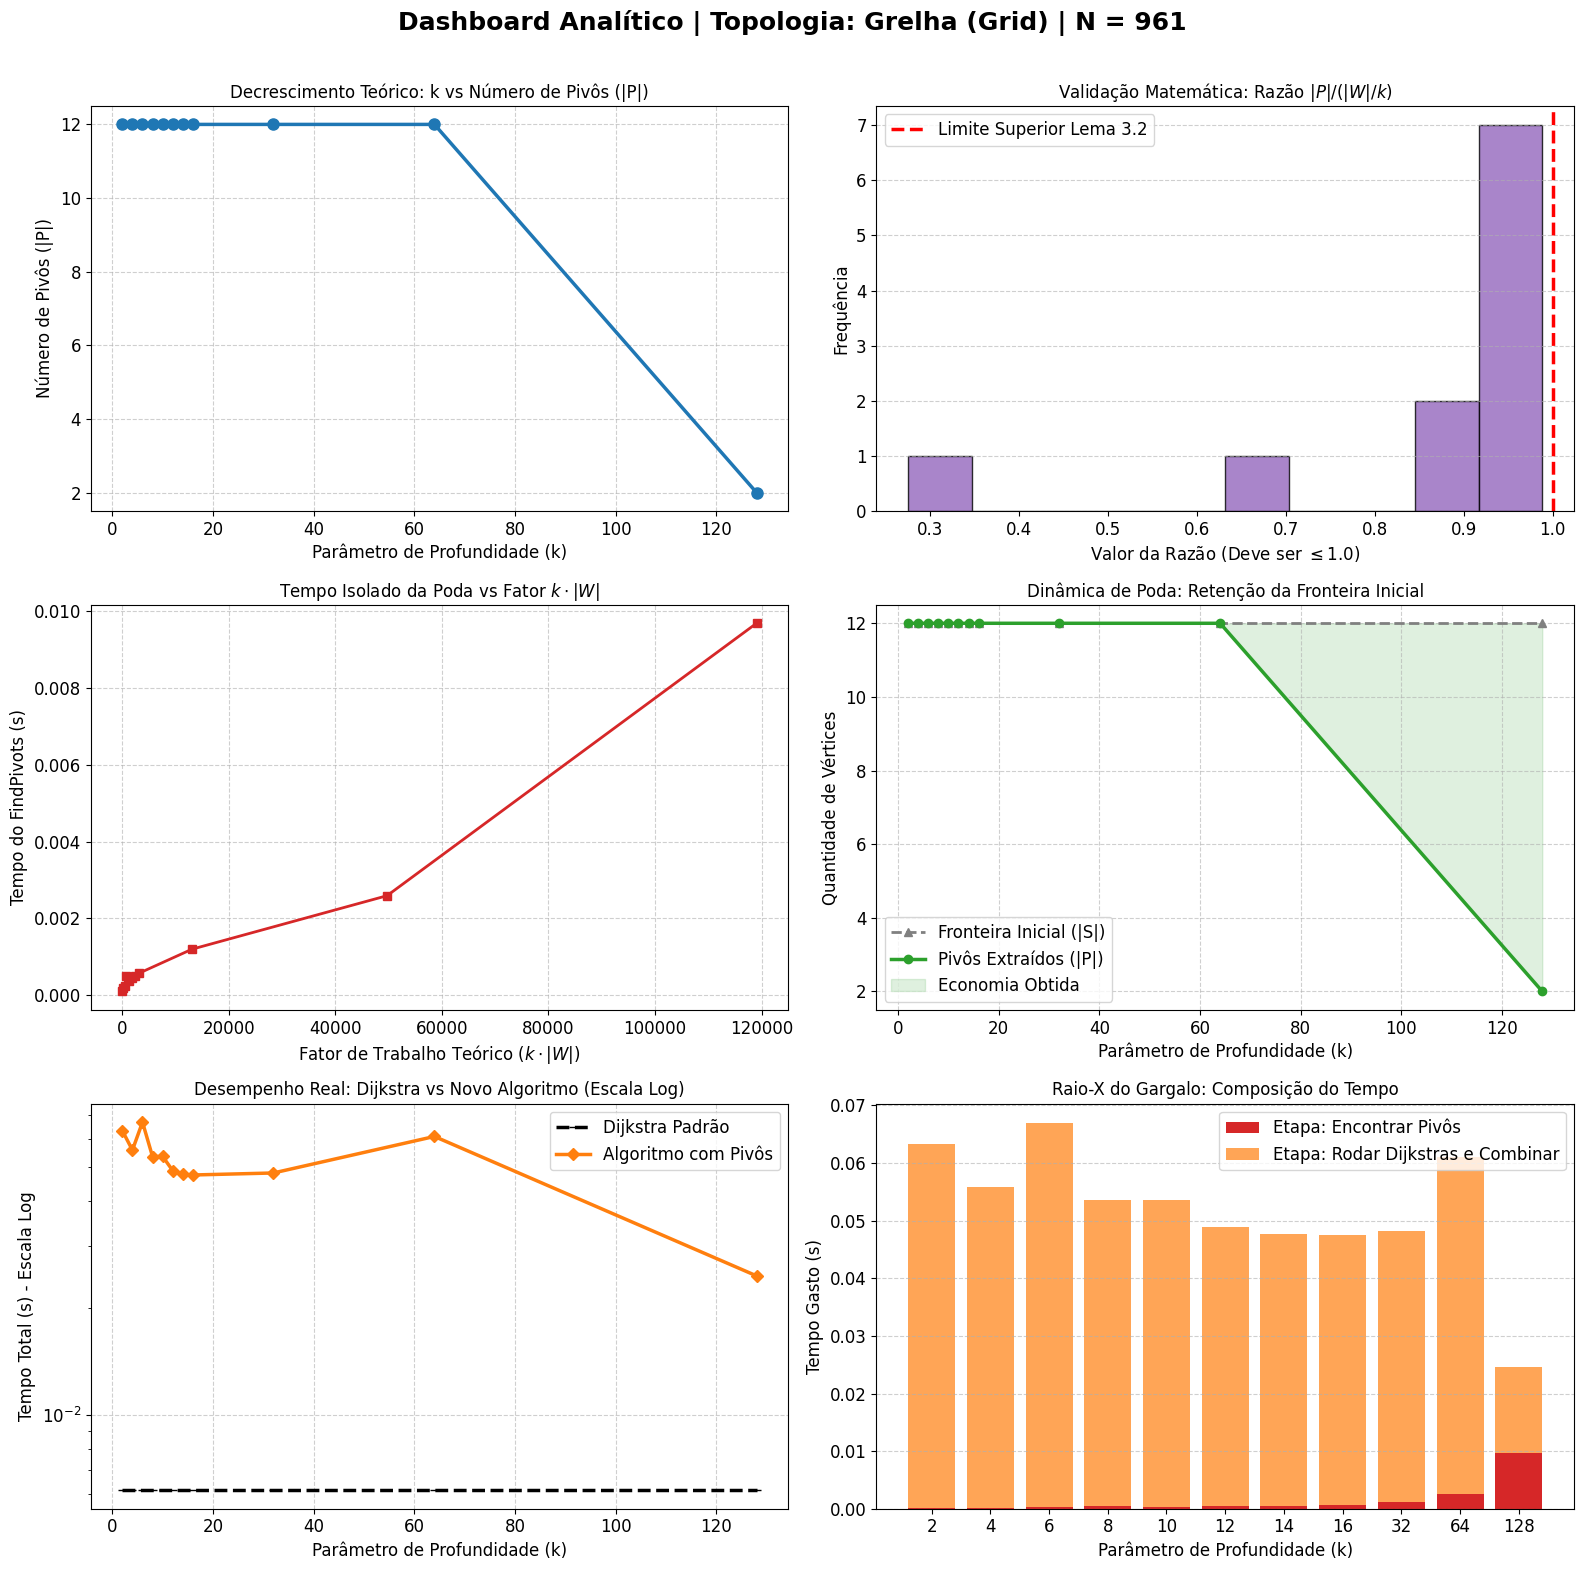

✅ Exportado: ../results/charts/grid/N_4900/dashboard_analise.png


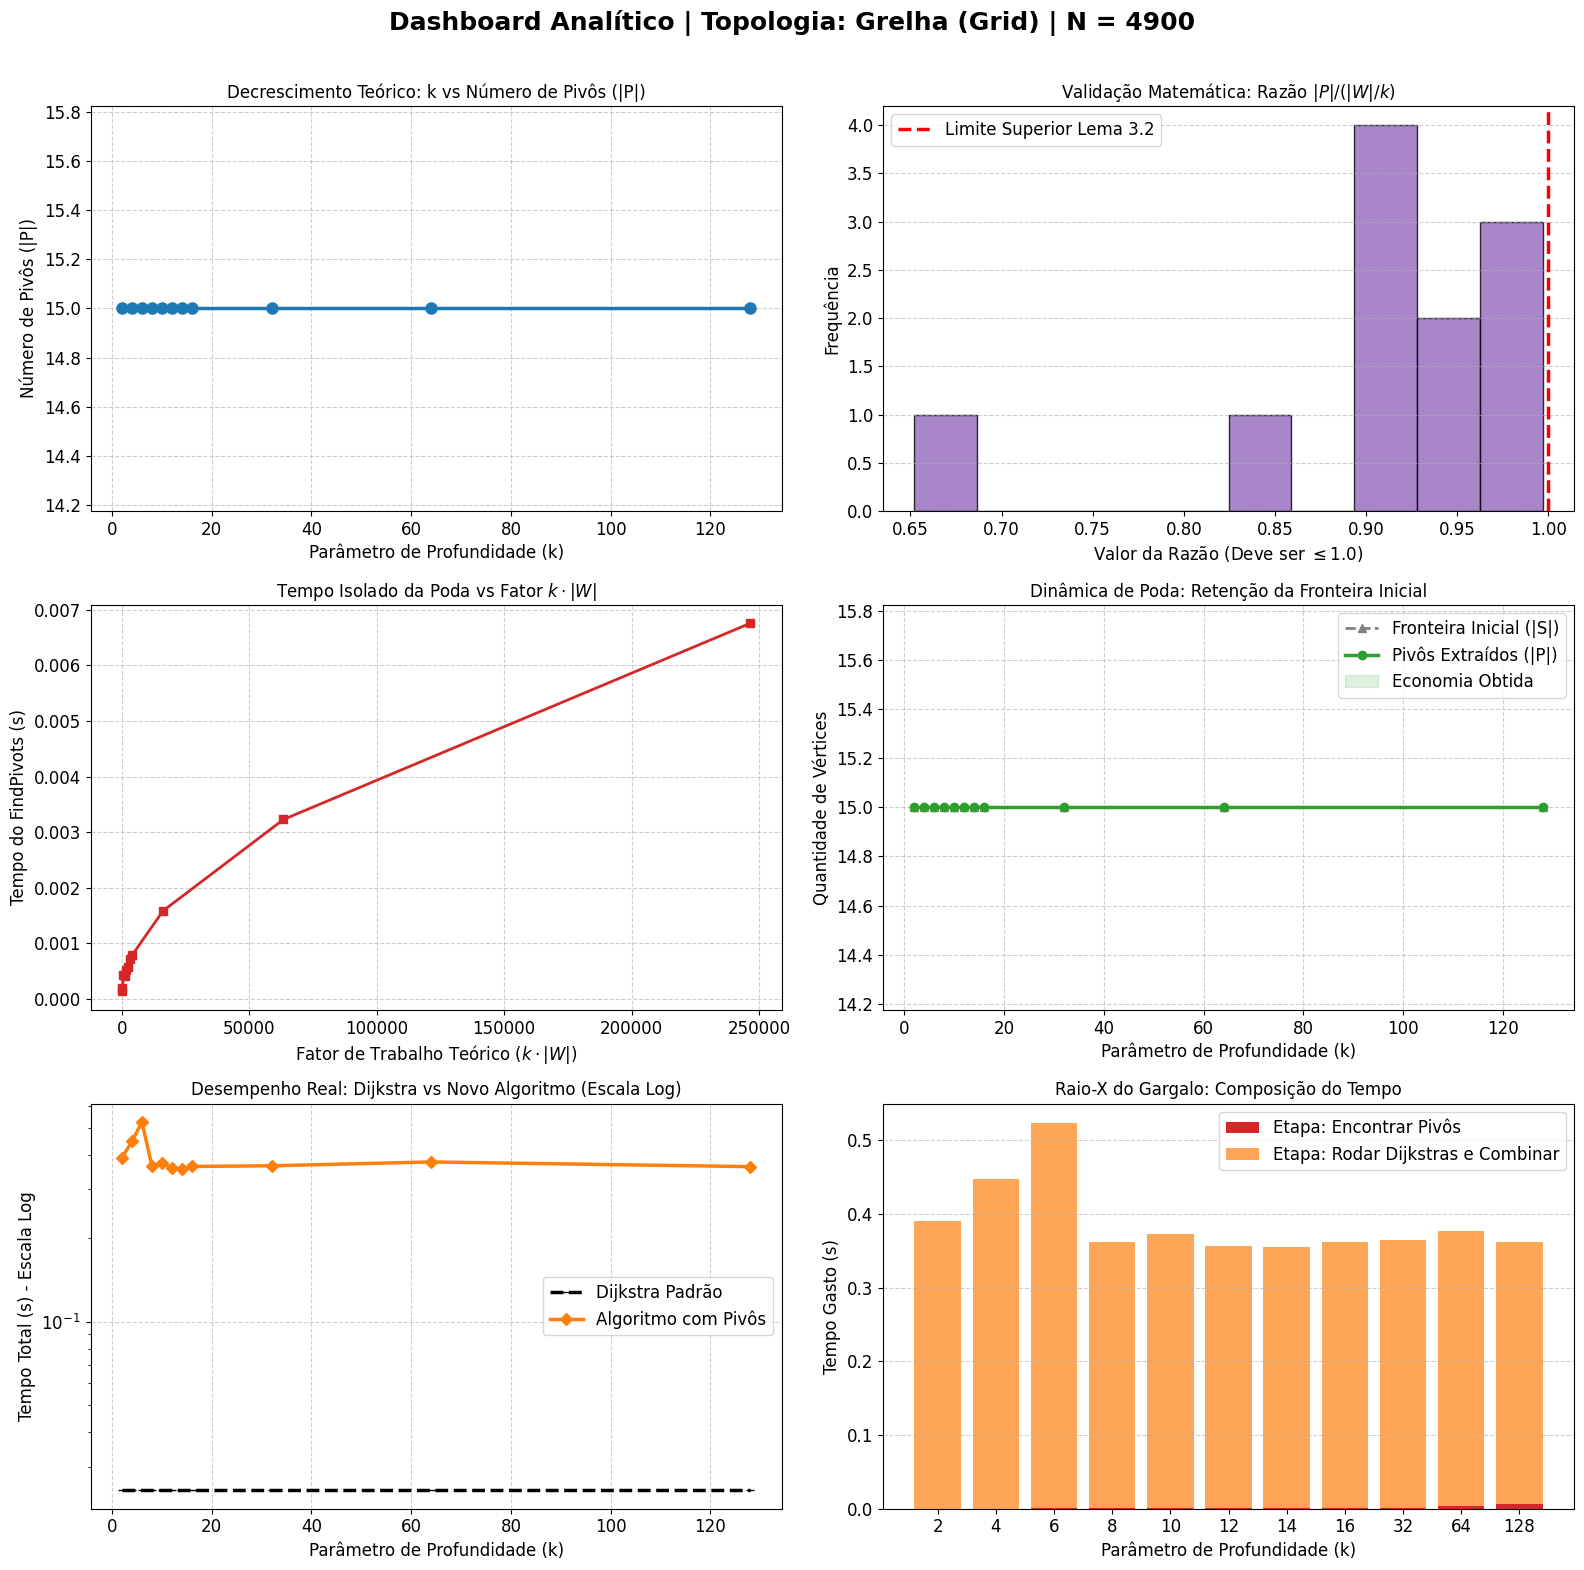

✅ Exportado: ../results/charts/grid/N_10000/dashboard_analise.png


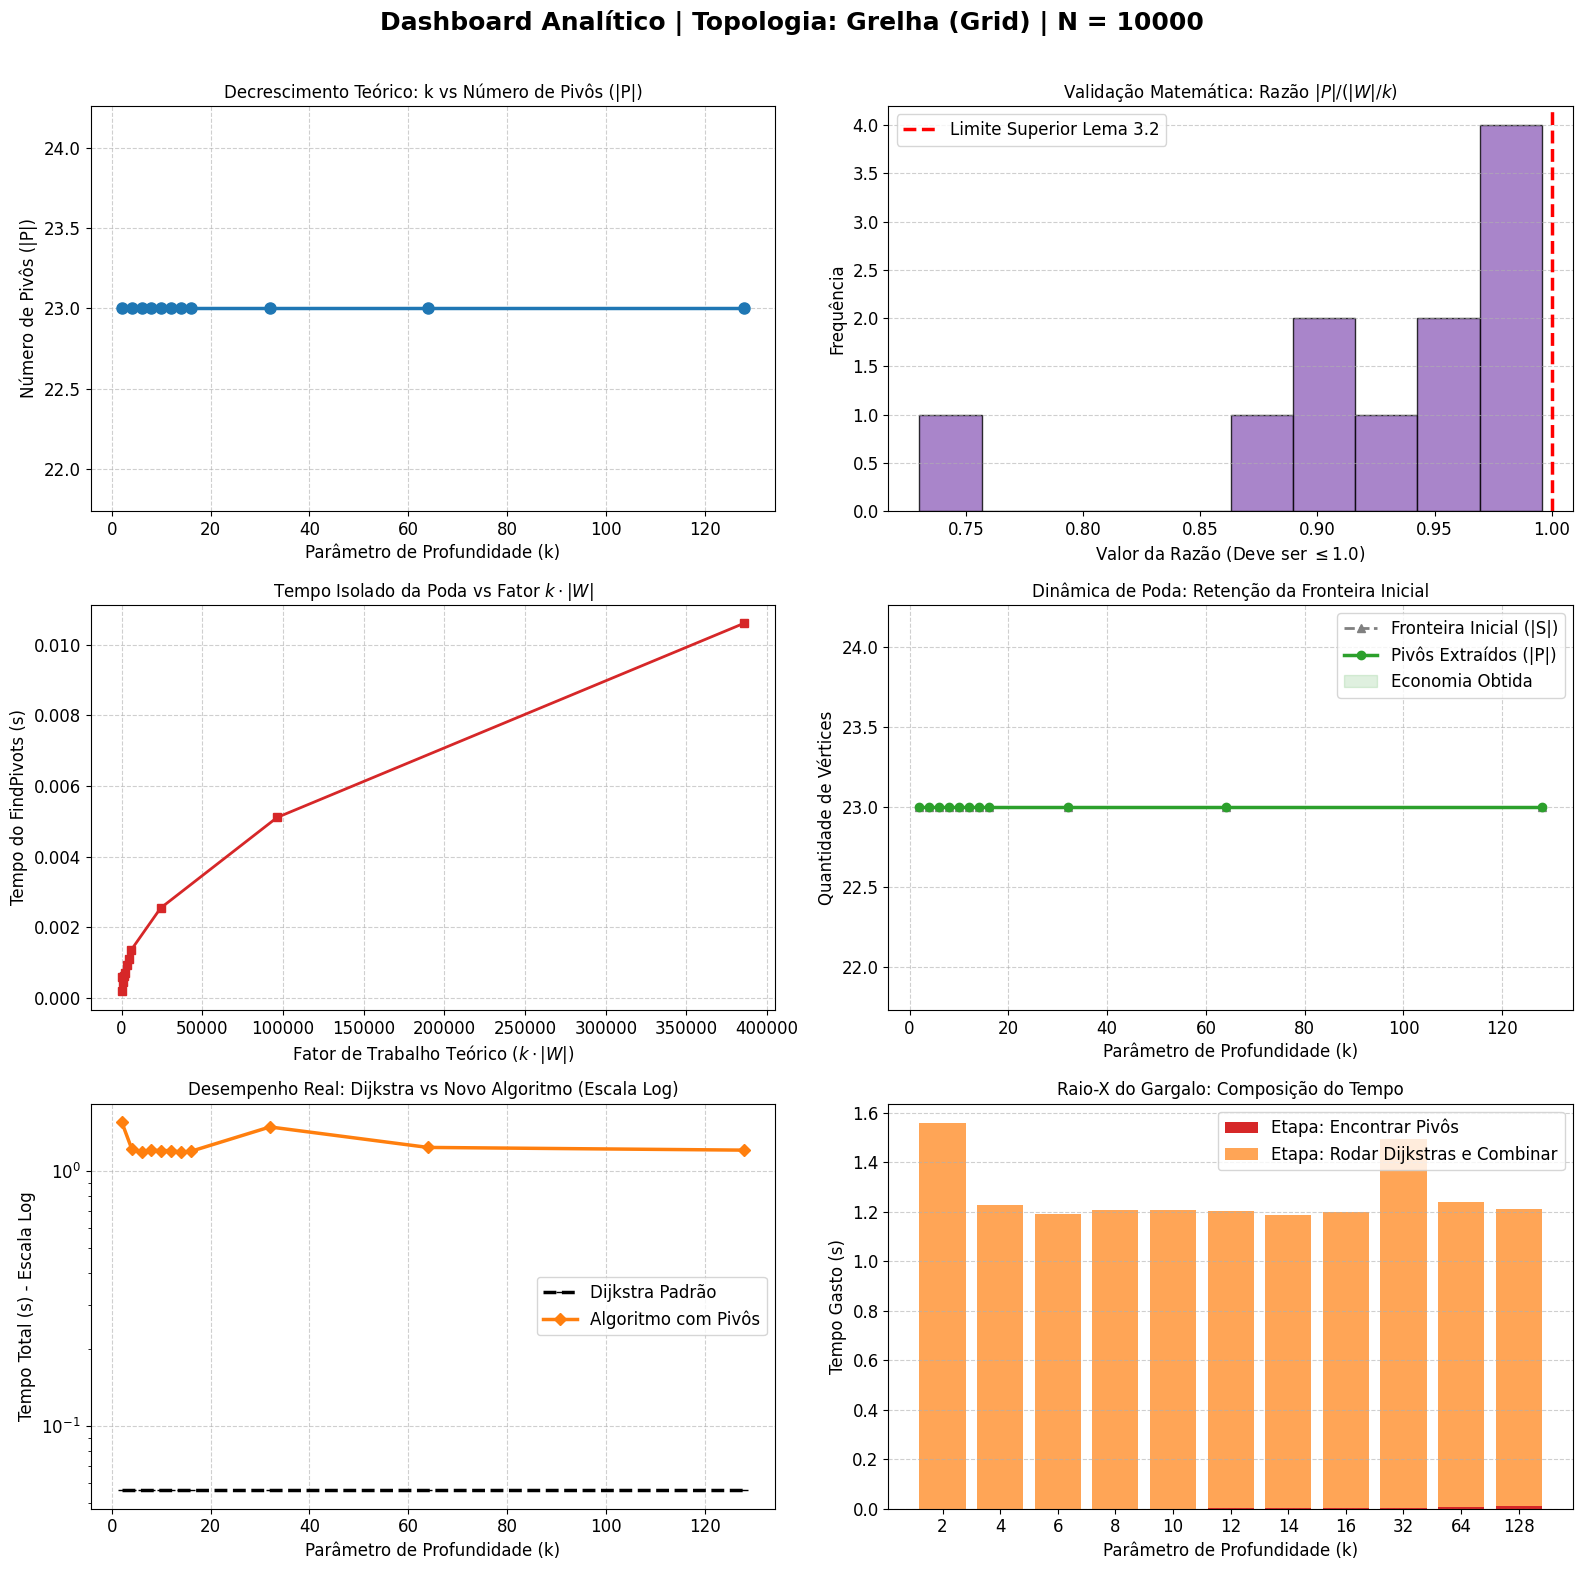


Geração de gráficos concluída!


In [31]:
# Lista com os CSVs dos Experimentos 2 e 3
csv_paths = [
    "../results/benchmark_exp2_sensitivity.csv",
    "../results/benchmark_exp3_grid.csv"
]

base_output_dir = "../results/charts"

for csv_path in csv_paths:
    if not os.path.exists(csv_path):
        print(f"Aviso: O arquivo '{csv_path}' não foi encontrado. Ignorando...")
        continue

    df_completo = pd.read_csv(csv_path)
    
    # Agrupa por Topologia (Type) e Tamanho (N)
    if 'Type' in df_completo.columns:
        grupos = df_completo.groupby(['Type', 'N'])
    else:
        grupos = df_completo.groupby('N')

    for key, df in grupos:
        tipo = key[0] if isinstance(key, tuple) else "desconhecido"
        n = key[1] if isinstance(key, tuple) else key
        
        # Garante a ordenação pelo parâmetro K
        df = df.sort_values(by='K').copy()
        
        nome_topologia = "Grelha (Grid)" if "grid" in str(tipo).lower() else "Aleatório Esparso"
        
        # Cria a pasta segmentada por Tipo e Tamanho (ex: results/charts/sparse_random/N_1000/)
        save_dir = os.path.join(base_output_dir, str(tipo), f"N_{n}")
        os.makedirs(save_dir, exist_ok=True)
        
        # Cria o Dashboard Expandido (3 Linhas x 2 Colunas)
        fig = plt.figure(figsize=(16, 16))
        gs = fig.add_gridspec(3, 2)
        fig.suptitle(f'Dashboard Analítico | Topologia: {nome_topologia} | N = {n}', 
                     fontsize=18, fontweight='bold')
        
        # ---------------------------------------------------------
        # 1. Gráfico: k vs |P|
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(df['K'], df['|P|'], marker='o', color='#1f77b4', linewidth=2.5, markersize=8)
        ax1.set_title('Decrescimento Teórico: k vs Número de Pivôs (|P|)', fontsize=12)
        ax1.set_xlabel('Parâmetro de Profundidade (k)')
        ax1.set_ylabel('Número de Pivôs (|P|)')
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        # ---------------------------------------------------------
        # 2. Histograma: distribuição de |P| / (|W|/k)
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.hist(df['Ratio |P|/(|W|/k)'].dropna(), bins=10, color='#9467bd', edgecolor='black', alpha=0.8)
        ax2.axvline(x=1.0, color='red', linestyle='dashed', linewidth=2.5, label='Limite Superior Lema 3.2')
        ax2.set_title('Validação Matemática: Razão $|P| / (|W|/k)$', fontsize=12)
        ax2.set_xlabel('Valor da Razão (Deve ser $\leq 1.0$)')
        ax2.set_ylabel('Frequência')
        ax2.legend()
        ax2.grid(axis='y', linestyle='--', alpha=0.6)
        
        # ---------------------------------------------------------
        # 3. Gráfico: Tempo Puro do FindPivots
        df_sorted_w = df.sort_values(by='k * |W|')
        ax3 = fig.add_subplot(gs[1, 0])
        ax3.plot(df_sorted_w['k * |W|'], df_sorted_w['FindPivots Only Time (s)'], 
                 marker='s', color='#d62728', linestyle='-', linewidth=2)
        ax3.set_title('Tempo Isolado da Poda vs Fator $k \cdot |W|$', fontsize=12)
        ax3.set_xlabel('Fator de Trabalho Teórico ($k \cdot |W|$)')
        ax3.set_ylabel('Tempo do FindPivots (s)')
        ax3.grid(True, linestyle='--', alpha=0.6)
        
        # ---------------------------------------------------------
        # 4. Dinâmica de Poda: |S| vs |P|
        ax4 = fig.add_subplot(gs[1, 1])
        ax4.plot(df['K'], df['|S|'], marker='^', color='gray', linestyle='--', linewidth=2, label='Fronteira Inicial (|S|)')
        ax4.plot(df['K'], df['|P|'], marker='o', color='#2ca02c', linewidth=2.5, label='Pivôs Extraídos (|P|)')
        ax4.fill_between(df['K'], df['|P|'], df['|S|'], color='#2ca02c', alpha=0.15, label='Economia Obtida')
        ax4.set_title('Dinâmica de Poda: Retenção da Fronteira Inicial', fontsize=12)
        ax4.set_xlabel('Parâmetro de Profundidade (k)')
        ax4.set_ylabel('Quantidade de Vértices')
        ax4.legend(loc='lower left' if df['|P|'].iloc[-1] < df['|S|'].iloc[-1] else 'best')
        ax4.grid(True, linestyle='--', alpha=0.6)

        # ---------------------------------------------------------
        # 5. NOVO: Comparação Pragmática (Dijkstra vs Otimizado)
        ax5 = fig.add_subplot(gs[2, 0])
        ax5.plot(df['K'], df['Dijkstra Base Time (s)'], marker='_', color='black', linestyle='--', linewidth=2.5, label='Dijkstra Padrão')
        ax5.plot(df['K'], df['Total Optimized Time (s)'], marker='D', color='#ff7f0e', linewidth=2.5, label='Algoritmo com Pivôs')
        ax5.set_title('Desempenho Real: Dijkstra vs Novo Algoritmo (Escala Log)', fontsize=12)
        ax5.set_xlabel('Parâmetro de Profundidade (k)')
        ax5.set_ylabel('Tempo Total (s) - Escala Log')
        ax5.set_yscale('log') # Escala Logarítmica para visualizar a diferença massiva
        ax5.legend()
        ax5.grid(True, linestyle='--', alpha=0.6)

        # ---------------------------------------------------------
        # 6. NOVO: Composição do Gargalo (Para onde vai o tempo?)
        ax6 = fig.add_subplot(gs[2, 1])
        tempo_poda = df['FindPivots Only Time (s)']
        tempo_gargalo = df['Total Optimized Time (s)'] - tempo_poda
        
        # Gráfico de barras empilhadas para k
        eixo_x = df['K'].astype(str)
        ax6.bar(eixo_x, tempo_poda, color='#d62728', label='Etapa: Encontrar Pivôs')
        ax6.bar(eixo_x, tempo_gargalo, bottom=tempo_poda, color='#ff7f0e', alpha=0.7, label='Etapa: Rodar Dijkstras e Combinar')
        ax6.set_title('Raio-X do Gargalo: Composição do Tempo', fontsize=12)
        ax6.set_xlabel('Parâmetro de Profundidade (k)')
        ax6.set_ylabel('Tempo Gasto (s)')
        ax6.legend()
        ax6.grid(axis='y', linestyle='--', alpha=0.6)
        
        # Ajustes finais e salvamento
        plt.tight_layout()
        plt.subplots_adjust(top=0.92) 
        
        save_path = os.path.join(save_dir, "dashboard_analise.png")
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Exportado: {save_path}")
        
        # Exibe no Jupyter
        plt.show()

print("\nGeração de gráficos concluída!")

<>:64: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:65: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:64: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:65: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_50292/3374409364.py:64: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.title('Tempo de Pré-processamento vs Fator $k \cdot |W|$')
/tmp/ipykernel_50292/3374409364.py:65: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future.

Gerando gráficos finais para o Relatório (N=1000, K até 16)...


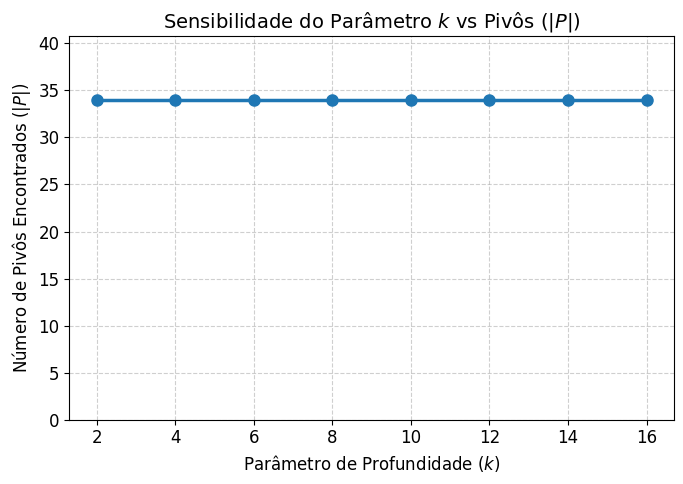

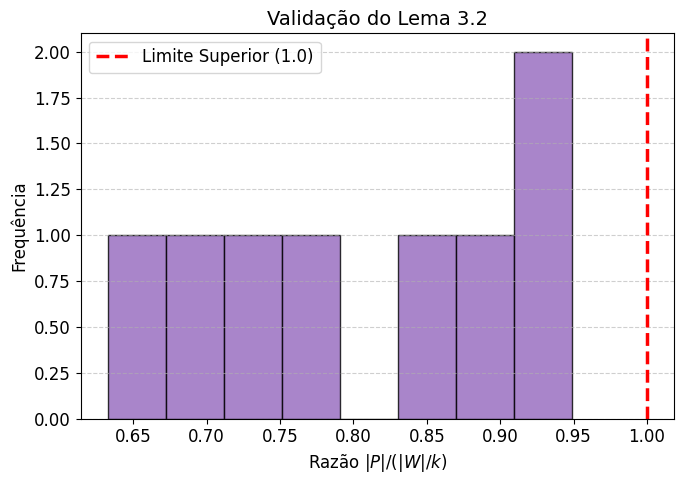

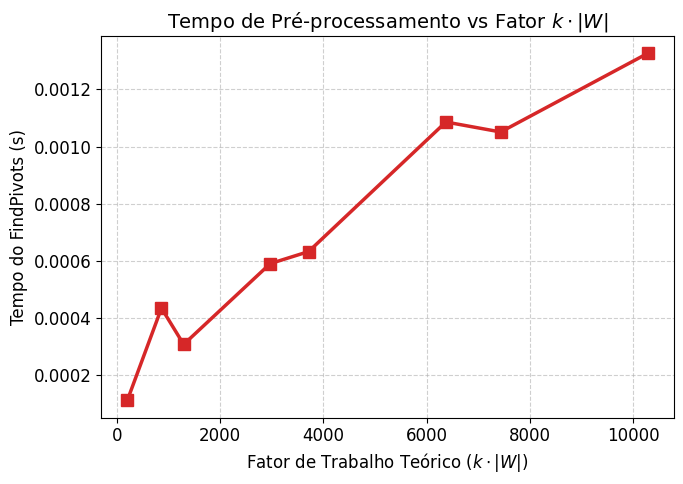

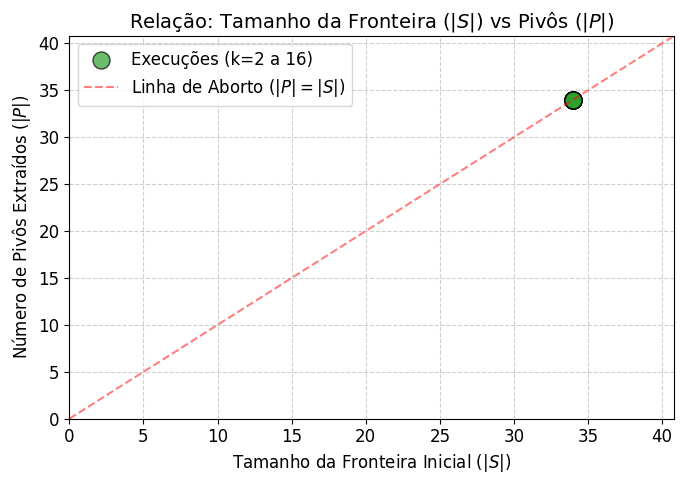


✅ Sucesso! 4 gráficos de alta resolução salvos em: '../results/charts/relatorio_final'


In [29]:
def gerar_graficos_finais_relatorio():
    csv_path = "../results/benchmark_exp2_sensitivity.csv"
    output_dir = "../results/charts/relatorio_final"
    os.makedirs(output_dir, exist_ok=True)

    try:
        df_completo = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Erro: Arquivo '{csv_path}' não encontrado.")
        return

    # FILTRO RIGOROSO PARA O RELATÓRIO: Apenas N=1000 e k de 2 até 16
    df = df_completo[(df_completo['N'] == 1000) & (df_completo['K'] <= 16)].copy()
    
    if df.empty:
        print("Nenhum dado encontrado para N=1000 e K<=16.")
        return

    # Garante ordenação correta para gráficos de linha
    df = df.sort_values(by='K')
    
    print(f"Gerando gráficos finais para o Relatório (N={df['N'].iloc[0]}, K até 16)...")

    # Configuração global de estilo para gráficos mais profissionais
    plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12})

    # =========================================================================
    # 1. Gráfico: k x |P|
    # =========================================================================
    plt.figure(figsize=(7, 5))
    plt.plot(df['K'], df['|P|'], marker='o', color='#1f77b4', linewidth=2.5, markersize=8)
    plt.title('Sensibilidade do Parâmetro $k$ vs Pivôs ($|P|$)')
    plt.xlabel('Parâmetro de Profundidade ($k$)')
    plt.ylabel('Número de Pivôs Encontrados ($|P|$)')
    # Força o eixo Y a começar do zero para mostrar a proporção real
    plt.ylim(0, df['|S|'].max() * 1.2) 
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/1_k_vs_P.png', dpi=300)
    plt.show()

    # =========================================================================
    # 2. Histograma: Validação do Lema 3.2
    # =========================================================================
    plt.figure(figsize=(7, 5))
    plt.hist(df['Ratio |P|/(|W|/k)'].dropna(), bins=8, color='#9467bd', edgecolor='black', alpha=0.8)
    plt.axvline(x=1.0, color='red', linestyle='dashed', linewidth=2.5, label='Limite Superior (1.0)')
    plt.title('Validação do Lema 3.2')
    plt.xlabel('Razão $|P| / (|W|/k)$')
    plt.ylabel('Frequência')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/2_histograma_lema.png', dpi=300)
    plt.show()

    # =========================================================================
    # 3. Gráfico: Tempo de execução vs. k * |W|
    # =========================================================================
    df_sorted_w = df.sort_values(by='k * |W|')
    plt.figure(figsize=(7, 5))
    plt.plot(df_sorted_w['k * |W|'], df_sorted_w['FindPivots Only Time (s)'], 
             marker='s', color='#d62728', linestyle='-', linewidth=2.5, markersize=8)
    plt.title('Tempo de Pré-processamento vs Fator $k \cdot |W|$')
    plt.xlabel('Fator de Trabalho Teórico ($k \cdot |W|$)')
    plt.ylabel('Tempo do FindPivots (s)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/3_tempo_vs_kw.png', dpi=300)
    plt.show()

    # =========================================================================
    # 4. Gráfico: |S| x |P| (Dispersão Clássica exigida pelo Roteiro)
    # =========================================================================
    plt.figure(figsize=(7, 5))
    plt.scatter(df['|S|'], df['|P|'], color='#2ca02c', s=150, alpha=0.7, edgecolors='black', label='Execuções (k=2 a 16)')
    # Linha de referência onde |P| = |S| (Nenhuma poda ocorreu)
    max_val = max(df['|S|'].max(), df['|P|'].max())
    plt.plot([0, max_val * 1.2], [0, max_val * 1.2], color='red', linestyle='--', alpha=0.5, label='Linha de Aborto ($|P|=|S|$)')
    
    plt.title('Relação: Tamanho da Fronteira ($|S|$) vs Pivôs ($|P|$)')
    plt.xlabel('Tamanho da Fronteira Inicial ($|S|$)')
    plt.ylabel('Número de Pivôs Extraídos ($|P|$)')
    plt.xlim(0, max_val * 1.2)
    plt.ylim(0, max_val * 1.2)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/4_S_vs_P.png', dpi=300)
    plt.show()

    print(f"\n✅ Sucesso! 4 gráficos de alta resolução salvos em: '{output_dir}'")

if __name__ == "__main__":
    gerar_graficos_finais_relatorio()